# Computation of Confidence Intervals for the Scalability Index 

***
>(c) Tobias Hossfeld (2026).
>
>This script is computing the confidence interval for the scalability index, which is defined in the following publication. Please cite upon usage:
> *Hossfeld, T., Heegaard, P. E., & Kellerer, W. (2023). Comparing the scalability of communication networks and systems. IEEE Access, 11, 101474-101497, [DOI 10.1109/ACCESS.2023.3314201](https://doi.org/10.1109/ACCESS.2023.3314201).*

***

This Jupyter notebook aims at demonstrating the computation of confidence intervals for the scalability index. Therefore, we generate synthetic measurement data for a given set of parameter values. For each parameter value, multiple measurement runs are created based on the underlying system function and additional random variability that mimics measurement noise and experimental uncertainty. Depending on the scenario, either a fixed or a random number of measurement runs can be generated for each parameter value.

Next, the **Scalability Index (SI)** is computed from the generated measurement data. The Scalability Index is a single-value metric that quantifies the scalability of a system (system under test, SUT) by comparing its behavior to that of a reference system (REF) over a specified parameter range. A target measure of interest, such as response time, throughput, availability, or failure rate, is described by a system function ($f(x)$), while the reference system is characterized by a reference function ($h(x)$). The parameter range under investigation can be weighted to reflect the importance or frequency of different operating conditions. The SI is then computed as the ratio of the weighted integral measurements (i.e., the weighted areas $F$ and $H$ under the system and reference curves), adjusted by a goodness indicator ($\gamma$), which accounts for whether larger values of the target measure are desirable ($\gamma=1$) or undesirable ($\gamma=-1$). As a result, the SI provides a normalized measure of how well the system scales relative to the chosen reference. More details can be found in [Hossfeld, T., Heegaard, P. E., & Kellerer, W. (2023). Comparing the scalability of communication networks and systems. IEEE Access, 11, 101474-101497](https://doi.org/10.1109/ACCESS.2023.3314201).

$$
SI = \left( \frac{F}{H}\right)^{\displaystyle \gamma} = \left( \frac{ \int_{a}^{b} f(x) \cdot w(x) \;dx }{ \int_{a}^{b} h(x) \cdot w(x) \;dx }\right)^{\displaystyle  \gamma}
$$

Finally, confidence intervals for the Scalability Index are estimated. These intervals quantify the statistical uncertainty of the SI estimate and provide a measure of confidence in the computed scalability assessment. The resulting confidence intervals allow evaluating whether observed differences in scalability are statistically significant and how robust the scalability conclusions are with respect to measurement variability and limited sample sizes.

## Generation of Measurement Data
The function `generateRandomMeasurementValues(x, h_fun, runs=35, randomRuns=False, seed=42)` generates synthetic measurement data for a set of parameter values `x`. For each parameter value, multiple measurement runs are created around the corresponding value of the reference system function `h_fun`, incorporating random variability to mimic measurement noise and experimental uncertainty. The number of generated runs can either be fixed for all parameter values (`runs`) or randomly selected when `randomRuns=True`. A random seed can be specified to ensure reproducibility of the generated data.

The measurements are obtained by adding positive random deviations to the ideal function values, where the noise follows a transformed normal distribution of the form $|N(\mu_i,\sigma_i)^{1.45}|/10 + 5$. This creates asymmetric variability with a positive offset, resulting in measurements that are systematically shifted above the ideal function and exhibit increasing dispersion.

In [1]:
import numpy as np
import random

def generateRandomMeasurementValues(x, h_fun, runs=35, randomRuns=False, seed=42): 
    """
    Generate random measurement values for a given set of parameter values.
    
    For each parameter value in `x`, multiple measurement runs are generated based
    on the optimal system function `h_fun` and additional random variability. The
    function can either use a fixed number of runs per parameter or a random number
    of runs.
    
    Args:
        x (array-like):
            Parameter values for which measurement data is generated.
    
        h_fun (callable):
            Optimal system function h(x) used to define random measurement values.
    
        runs (int, optional):
            (Average) number of measurement runs per parameter value.
            Defaults to 35.
    
        randomRuns (bool, optional):
            If True, a random number of measurement runs is generated for each
            parameter value. If False, a fixed number of runs (`runs`) is used.
            Defaults to False.
    
        seed (int, optional):
            Random seed for reproducibility of the generated measurement values.
            Defaults to 42.
    
    Returns:
        numpy.ndarray or list:
            Generated measurement values. The exact structure depends on the
            implementation (e.g., a matrix y[x, i] or a list of measurement vectors).
    
    Notes:
        This function is intended for simulation and testing purposes, for example
        when evaluating scalability indices (SI) or confidence intervals.
    """
     
    random.seed(seed)
    np.random.seed(seed)
    k = len(x) 
    
    mus = 2*np.arange(k)**1.4 + 20 # 
    stds = (np.arange(k)+5)
    if randomRuns:
        y2 = []        
        for i in range(k):
            r = random.randint(runs-10, runs+10)  # random number of runs
            y2.append( h_fun(x[i]) + np.abs(np.random.normal(loc=mus[i], scale=stds[i], size=r)**1.45)/10 +5 )
        return y2
    else:
        y = np.zeros((k, runs)) # measurements values y_x,i for paramter x and repetition i                 
        for i in range(k):    
            y[i,:] = h_fun(x[i]) + np.abs(np.random.normal(loc=mus[i], scale=stds[i], size=runs)**1.45)/10 +5
            
        return y
    

### Example Measurement Data
In this example, synthetic measurement data are generated for (k=15) parameter values, corresponding to $x=1,\ldots,15$. The reference system is described by the ideal function $h(x)=x^{1.65}$, which defines the expected behavior of the target measure as the parameter increases. For each parameter value, 35 measurement runs are generated, resulting in repeated observations around the ideal function value while incorporating random variability to emulate measurement noise. Additionally, a weight function $w(x)=2\sqrt{x}+1$ is defined to assign increasing importance to larger parameter values when computing weighted integral measurements and the Scalability Index. The resulting dataset $y$ therefore consists of noisy measurements of the ideal system behavior across the considered parameter range.

A single measurement $y_{i,k}$ provides the target measure of interest for the parameter setting $x_i$ and the $k$-th measurement run.

In [12]:
k = 15 # parameter settings
runs = 35 # number of measurement runs per setting
h = lambda x: x**1.65 # ideal function
x = np.arange(1,k+1) # parameter values
wx = lambda x: 2*x**0.5+1 # weightfunction
y = generateRandomMeasurementValues(x, h, runs=runs, randomRuns=False)
print(f"There are {k} parameter settings. For every parameter setting {runs} are conducted. The measurements are stored in the array y with shape {y.shape}.")

There are 15 parameter settings. For every parameter setting 35 are conducted. The measurements are stored in the array y with shape (15, 35).


The plot visualizes the synthetic measurement data of the system under test (SUT) together with the corresponding reference system. For each parameter value $x_i$, the individual measurement runs $y_{i,k}$ are shown as points, illustrating the variability and uncertainty of the observed measurements. The estimated mean value $\hat{y}_i=f(x_i)$ of the measurements at each parameter setting is depicted by connected markers and represents the target measure function of the SUT. In addition, the ideal reference function $h(x)$ is shown as a continuous curve, serving as the target measure function of the reference system (REF). The plot highlights both the dispersion of the measurement data around their mean values and the deviation of the SUT behavior from the reference system across the investigated parameter range.

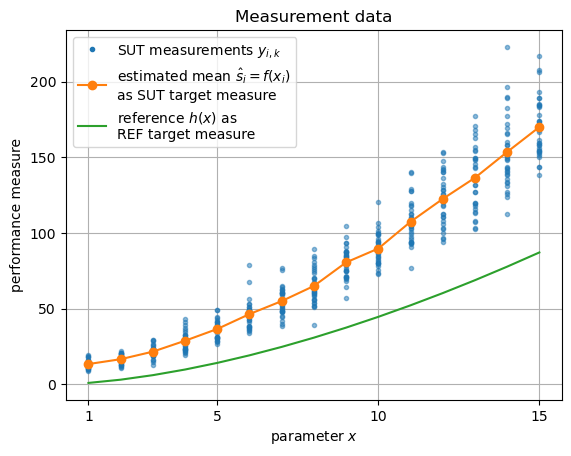

In [3]:
import matplotlib.pyplot as plt 
#%% visualize the measurement results
plt.plot(x, y, '.', color=plt.cm.tab20(0), alpha=0.5)
plt.plot(np.nan, np.nan, ".",  color=plt.cm.tab20(0),  label="SUT measurements $y_{i,k}$")
plt.plot(x, y.mean(axis=1), 'o-', color=plt.cm.tab10(1), label='estimated mean $\\hat{s}_i=f(x_i)$\nas SUT target measure')
plt.plot(x, h(x), color=plt.cm.tab10(2), label='reference $h(x)$ as \nREF target measure')
plt.xlabel('parameter $x$')
plt.ylabel('performance measure')
plt.title('Measurement data')
plt.legend()
plt.grid(which='major')
plt.xticks([1,5,10,15])
plt.show();

## Computation of the SI

The estimated mean values $\hat{y}_i=f(x_i)$, obtained by averaging the repeated measurements for each parameter value, are used as the target measure function of the system under test (SUT). Together with the reference function $h(x)$, these curves form the input for the Scalability Index (SI) calculation. To quantify the overall behavior of both systems over the considered parameter range, the weighted areas under the curves are computed, yielding the integral measurements $F$ and $H$. The SI is then obtained by comparing these integral measurements according to the SI definition, resulting in a single-value assessment of the scalability of the SUT relative to the reference system.

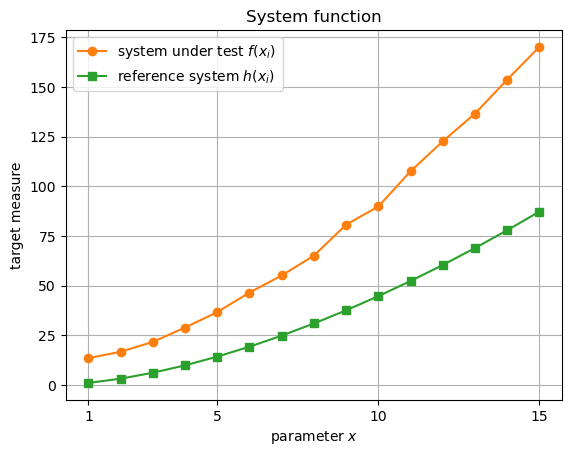

In [4]:
plt.plot(x, y.mean(axis=1), 'o-', color=plt.cm.tab10(1), label='system under test $f(x_i)$ ')
plt.plot(x, h(x), 's-', color=plt.cm.tab10(2), label='reference system $h(x_i)$ ')
plt.xlabel('parameter $x$')
plt.ylabel('target measure')
plt.title('System function')
plt.legend()
plt.grid(which='major')
plt.xticks([1,5,10,15])
plt.show();

### Equidistant measurements
In this example, measurements are conducted at uniformly spaced intervals of length $\Delta x$. The parameter settings used in the measurements are $
x_i = i \cdot \Delta x + x_0,$ for $i = 1, \ldots, n$. In particular, it is $x_i=i$ in that example.

The weighted areas under the corresponding curves are approximated by
$$
F = \sum_{i=1}^{n} \Delta x \cdot f(x_i) \cdot w(x_i), \qquad H = \sum_{i=1}^{n} \Delta x \cdot h(x_i) \cdot w(x_i),
$$

for the SUT and REF, respectively.

Consequently, the Scalability Index  is obtained as the ratio of the weighted integral measurements,

$$
SI = \left(\frac{F}{H}\right)^\gamma
    = \left(
        \frac{\sum_{i=1}^{n} f(x_i) \cdot w(x_i)}
             {\sum_{i=1}^{n} h(x_i) \cdot w(x_i)}
      \right)^\gamma,
$$

where $\gamma\in\{-1,1\}$ indicates whether the target measure represents goodness ($\gamma=1$) or badness ($\gamma=-1$).

In [6]:
def computeSI(y, x, h_fun, w_fun, gamma=1):   
    """
    Compute the scalability index (SI) based on measurement data and weighting.
    
    Args:
        y (numpy.ndarray or list):
            Measurement values. If a NumPy array is provided, it is interpreted as
            a matrix y[x, i], where x indexes the parameter and i the measurement
            run. If a list is provided, it is interpreted as a list of measurement
            vectors, one per parameter value.
    
        x (array-like):
            Parameter values corresponding to the measurements.
    
        h_fun (callable):
            Optimal system function h(x), evaluated for the parameter values x.
    
        w_fun (callable):
            Weight function w(x), evaluated for the parameter values x.
    
        gamma (float, optional):
            Exponent applied to the ratio (H / F).
            Defaults to 1.
    
    Returns:
        float:
            The computed scalability index (SI).
    
    Raises:
        TypeError:
            If y is neither a NumPy array nor a list of measurement vectors.
    """

    H = np.sum(h_fun(x)*w_fun(x))
    
    if isinstance(y, np.ndarray): # matrix
        y_x = np.mean(y, axis=1)
    elif isinstance(y, list): # list of vectors
        y_x = [y_i.mean()  for y_i in y]
    else:
        raise TypeError("y must be a numpy array or a list of vectors")
    
    F = np.sum(y_x*w_fun(x))
    return (H/F)**gamma

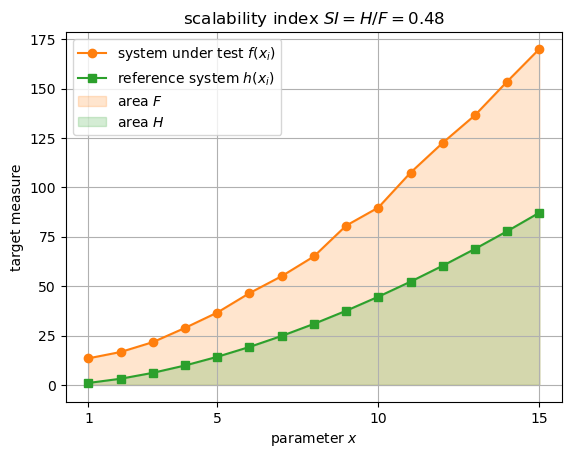

SI: 0.4810


In [7]:
SI = computeSI(y, x, h, wx)

plt.plot(x, y.mean(axis=1), 'o-', color=plt.cm.tab10(1),
         label='system under test $f(x_i)$')
plt.plot(x, h(x), 's-', color=plt.cm.tab10(2),
         label='reference system $h(x_i)$')

# fill areas under the curves
plt.fill_between(x, 0, y.mean(axis=1),
                 color=plt.cm.tab10(1), alpha=0.2,
                 label='area $F$')

plt.fill_between(x, 0, h(x),
                 color=plt.cm.tab10(2), alpha=0.2,
                 label='area $H$')

plt.xlabel('parameter $x$')
plt.ylabel('target measure')
plt.title(f'scalability index $SI=H/F={SI:.2f}$')
plt.legend()
plt.grid(which='major')
plt.xticks([1, 5, 10, 15])
plt.show()

print(f"SI: {SI:.4f}");

## Computation of the Confidence Interval for the SI: Bootstrapping
To quantify the uncertainty of the estimated Scalability Index (SI), a confidence interval is computed using bootstrap resampling. The bootstrap procedure repeatedly draws new measurement samples with replacement from the original measurement data and recomputes the SI for each resample. This results in an empirical distribution of SI values that reflects the variability caused by finite and noisy measurements. Based on this distribution, confidence bounds are determined according to the chosen significance level $\alpha$. For example, $\alpha=0.05$ yields a 95% confidence interval. The resulting interval provides a statistical measure of the precision and reliability of the estimated scalability index and indicates the range of SI values that are consistent with the observed measurement data.

In [8]:
def computeCI(y, x, h_fun, w_fun, gamma=1, resample=15000, alpha=0.05):    
    """
    Compute a confidence interval (CI) for the scalability index using bootstrapping.
    
    The confidence interval is estimated by resampling the measurement data and
    recomputing the scalability index multiple times.
    
    Args:
        y (numpy.ndarray or list):
            Measurement values. If a NumPy array is provided, it is interpreted as
            a matrix y[x, i], where x indexes the parameter and i the measurement
            run. If a list is provided, it is interpreted as a list of measurement
            vectors, one per parameter value.
    
        x (array-like):
            Parameter values corresponding to the measurements.
    
        h_fun (callable):
            Optimal system function h(x), evaluated for the parameter values x.
    
        w_fun (callable):
            Weight function w(x), evaluated for the parameter values x.
    
        gamma (float, optional):
            Exponent applied to the scalability index.
            Defaults to 1.
    
        resample (int, optional):
            Number of bootstrap resamples used to estimate the confidence interval.
            Defaults to 15000.
    
        alpha (float, optional):
            Significance level of the confidence interval.
            A value of 0.05 corresponds to a 95% confidence level.
            Defaults to 0.05.
    
    Returns:
        tuple:
            A tuple ``(SIconfis, SI, bootstrap_samples)`` where
    
            - ``SIconfis`` (numpy.ndarray): Lower and upper bounds of the
              estimated confidence interval for the Scalability Index,
              corresponding to the quantiles
              ``[alpha/2, 1-alpha/2]`` of the bootstrap distribution.
    
            - ``SI`` (float): Scalability Index computed from the original
              measurement data.
    
            - ``bootstrap_samples`` (numpy.ndarray): Bootstrap distribution
              of the Scalability Index obtained from all resampled datasets.

    
    Raises:
        TypeError:
            If y is neither a NumPy array nor a list of measurement vectors.
    """    
    H = np.sum(h_fun(x)*w_fun(x))
        
    if isinstance(y, np.ndarray): # matrix
        y_x = np.mean(y, axis=1)        
        F = np.sum(y_x*w_fun(x))
        SI = (H/F)**gamma
        
        k, runs = y.shape
        
        res = np.zeros((k, resample))
        for i in range(k):    
            tmp = np.random.choice(y[i,:], size=(runs, resample), replace=True)
            res[i,:] = np.mean(tmp,axis=0)*w_fun(x[i]) # average performance
        sampleSums = res.sum(axis=0) # SI integral                                
    elif isinstance(y, list): # list of vectors
        y_x = [y_i.mean()  for y_i in y]
        F = np.sum(y_x*w_fun(x))
        SI = (H/F)**gamma
        
        k = len(y)
        res = np.zeros((k, resample))
        for i in range(k):    
            tmp = np.random.choice(y[i], size=(len(y[i]), resample), replace=True)
            res[i,:] = np.mean(tmp,axis=0)*w_fun(x[i]) # average performance
        sampleSums = res.sum(axis=0) # SI integral                
    else:
        raise TypeError("y must be a numpy array or a list of vectors")
    
    bootstrap_samples = (H/sampleSums)**gamma
    SIconfis = np.quantile(bootstrap_samples,[alpha/2,1-alpha/2])
        
    return SIconfis, SI, bootstrap_samples

SI: 0.4810
SI: 0.4810 in [0.4741; 0.4881]


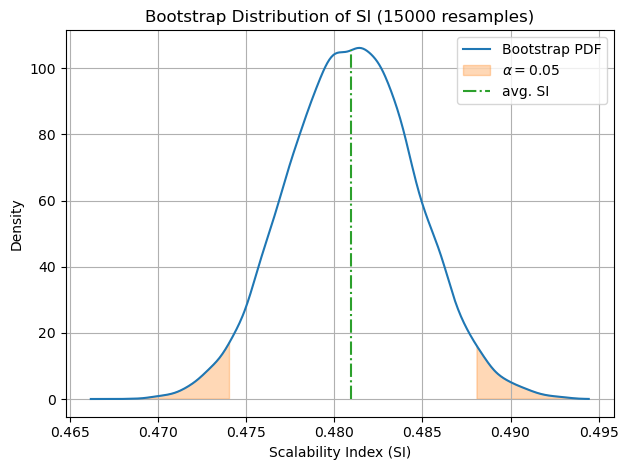

In [26]:
alpha = 0.05
SIconfis, SI, bootstrap_samples = computeCI(y,x,h,wx, alpha=alpha)
print(f"SI: {computeSI(y, x, h, wx):.4f}")
print(f'SI: {SI:.4f} in [{SIconfis[0]:.4f}; {SIconfis[1]:.4f}]')

# plot empirical PDF / bootstrap distribution
from scipy.stats import gaussian_kde

xx = np.linspace(min(bootstrap_samples), max(bootstrap_samples), 500)
pdf = gaussian_kde(bootstrap_samples)
yy = pdf(xx)
y_lo = pdf(SIconfis[0])[0]
y_hi = pdf(SIconfis[1])[0]
y_si = pdf(SI)[0]

plt.plot(xx, yy, label='Bootstrap PDF') # plot bootstrap distribution (PDF)

# fill areas outside confidence interval
plt.fill_between(xx, 0, yy, where=(xx <= SIconfis[0]) | (xx >= SIconfis[1]),
                 alpha=0.3, color=plt.cm.tab10(1), label=fr'$\alpha={alpha}$')
plt.vlines(SI, 0, y_si, linestyle='-.', label='avg. SI', color=plt.cm.tab10(2))

plt.xlabel('Scalability Index (SI)')
plt.ylabel('Density')
plt.grid()
plt.title(f'Bootstrap Distribution of SI ({len(bootstrap_samples)} resamples)')
plt.legend()
plt.tight_layout()
plt.show()

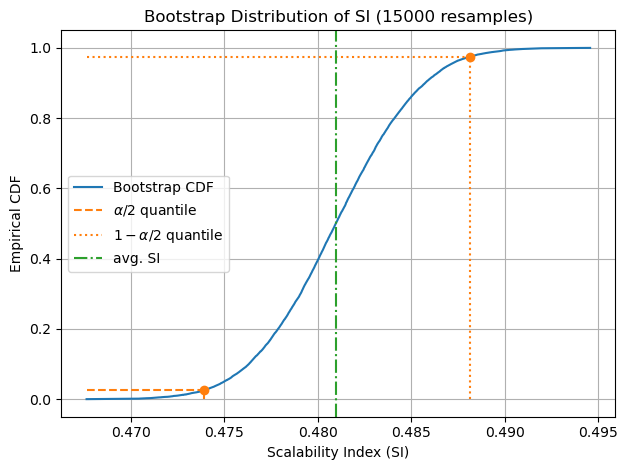

In [25]:
# plot bootstrap distribution as CDF
x_cdf = np.sort(bootstrap_samples)
y_cdf = np.arange(1, len(x_cdf)+1) / len(x_cdf)
plt.plot(x_cdf, y_cdf, label='Bootstrap CDF')
plt.vlines(SIconfis[0], 0, alpha/2, linestyle='--', label=fr'$\alpha/2$ quantile', color=plt.cm.tab10(1))
plt.vlines(SIconfis[1], 0, 1-alpha/2, linestyle=':', label=fr'$1-\alpha/2$ quantile', color=plt.cm.tab10(1))
# horizontal quantile levels
plt.hlines(alpha/2, x_cdf.min(), SIconfis[0], linestyle='--', color=plt.cm.tab10(1))
plt.hlines(1-alpha/2, x_cdf.min(), SIconfis[1], linestyle=':', color=plt.cm.tab10(1))
plt.axvline(SI, label="avg. SI", ls="-.", color=plt.cm.tab10(2))

# mark quantile points
plt.plot(SIconfis, [alpha/2, 1-alpha/2], 'o')

plt.xlabel('Scalability Index (SI)')
plt.ylabel('Empirical CDF')
plt.title(f'Bootstrap Distribution of SI ({len(bootstrap_samples)} resamples)')
plt.grid(True)
plt.legend(loc="center left")
plt.tight_layout()
plt.show()

### Confidence Intervals Using Normal Distribution Assumption

Assuming that the estimator $\hat{F}$ of the weighted area under the system curve is approximately normally distributed, it can be characterized by its estimated mean $\hat{\mu}$ and standard error $\hat{\varepsilon}$. Since the estimated target measures $\hat{y}_i$ and the corresponding area contributionsare assumed to be independent, the standard error of the area estimator can be derived from the variances of the individual contributions. Under the normality assumption, a confidence interval for $\hat{F}$ is obtained using the critical value $z_{\alpha/2}$ of the standard normal distribution. For a 95\% confidence interval, $z_{\alpha/2}=1.96$. By propagating this uncertainty to the Scalability Index, the resulting confidence interval with significance level $\alpha$ is given by

$$
SI \in \left[
\frac{H}{\hat{\mu} + z_{\alpha/2}\hat{\varepsilon}},
\;
\frac{H}{\hat{\mu} - z_{\alpha/2}\hat{\varepsilon}}
\right].
$$

This interval quantifies the statistical uncertainty of the estimated scalability index and provides a range of plausible scalability values that are consistent with the observed measurement data.

In [27]:
H = np.sum(h(x)*wx(x))
mu = np.sum(np.mean(y,axis=1)*wx(x))
sigma = np.sqrt(np.sum(y.var(axis=1, ddof=1)*wx(x)**2)/runs)

print(f"Area under curve for SUT: F={mu:.2f}")
print(f"Area under curve for REF: H={H:.2f}")
print(f"SI = H/F ={H/mu:.4f}={computeSI(y, x, h, wx):.4f}")

print(f'bootstrapped CI: SI [{SIconfis[0]:.3f}; {SIconfis[1]:.3f}]')
print(f'estimated (norm.) CI: [{H/(mu+1.96*sigma):.3f}; {H/(mu-1.96*sigma):.3f}]')


Area under curve for SUT: F=8525.57
Area under curve for REF: H=4100.51
SI = H/F =0.4810=0.4810
bootstrapped CI: SI [0.474; 0.488]
estimated (norm.) CI: [0.474; 0.488]
